In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import pandas as pd

In [2]:
##READ IN THE DATA USING PANDAS
stud = pd.read_csv("C:/Users/Durosimi/PROJECTS/mlproject/src/notebook/data/stud.csv")

In [3]:
stud.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [5]:
stud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
stud.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
stud.shape

(1000, 8)

In [8]:
stud.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [9]:
# CHECK FOR NULL VALUES IN THE DATA
stud.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [10]:
stud.duplicated().sum()

0

In [11]:
stud.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [12]:
stud['gender'].unique()


array(['female', 'male'], dtype=object)

In [13]:
stud['race_ethnicity'].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [14]:
stud['parental_level_of_education'].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [15]:
stud['lunch'].unique()

array(['standard', 'free/reduced'], dtype=object)

CHECKING FOR NUMERIC AND CATEGORICAL FEATURES

In [17]:
## Using List comprehension to check for numeric features
numeric_feature = [feature for feature in stud.columns if stud[feature].dtype != '0']

In [18]:
numeric_feature
print(f"We have {len(numeric_feature)} numbers of categorical features: {numeric_feature}")

We have 8 numbers of categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'math_score', 'reading_score', 'writing_score']


In [19]:
## Using list comprhension to check for categorical features
categorical_feature = [feature for feature in stud.columns if stud[feature].dtype == object]

In [20]:
categorical_feature
print(f"We have {len(categorical_feature)} numbers of categorical features: {categorical_feature}")

We have 5 numbers of categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


ADD COLUMNS FOR AVERAGE SCORE AND TOTAL SCORE

In [22]:
stud.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [23]:
stud["total_score"] = stud["math_score"] + stud["reading_score"] + stud["writing_score"] 

In [24]:
stud["average_score"] = stud['total_score']/3

In [25]:
stud.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [26]:
## CHECKING FOR THE LARGEST SCORES
stud["average_score"].nlargest()

458    100.000000
916    100.000000
962    100.000000
114     99.666667
179     99.000000
Name: average_score, dtype: float64

In [27]:
stud.iloc[[458, 916, 962, 114, 179]]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
458,female,group E,bachelor's degree,standard,none,100,100,100,300,100.000000
916,male,group E,bachelor's degree,standard,completed,100,100,100,300,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,300,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,299,99.666667
179,female,group D,some high school,standard,completed,97,100,100,297,99.000000


CHECKING FOR THE NUMBER OF PUPILS THAT HAVE AN AVERGAE OF 100 IN THEIR MATH SCORE

In [29]:
math = stud[stud['math_score'] == 100]['average_score'].count()
print(f'{math} students have an average of 100 in Math')

7 students have an average of 100 in Math


In [30]:
## THE STUDENTS THAT HAVE A SCORE OF 100 IN THEIR MATH SCORE.
stud[stud['math_score'] == 100]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
149,male,group E,associate's degree,free/reduced,completed,100,100,93,293,97.666667
451,female,group E,some college,standard,none,100,92,97,289,96.333333
458,female,group E,bachelor's degree,standard,none,100,100,100,300,100.000000
623,male,group A,some college,standard,completed,100,96,86,282,94.000000
625,male,group D,some college,standard,completed,100,97,99,296,98.666667
916,male,group E,bachelor's degree,standard,completed,100,100,100,300,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,300,100.000000


CHECKING FOR THE NUMBER OF PUPILS THAT HAVE AN AVERGAE OF 100 IN THEIR WRITING SCORE

In [32]:
writing = stud[stud['writing_score'] == 100]['average_score'].count()
print(f"{writing} students have an average of 100 in Writing")

14 students have an average of 100 in Writing


CHECKING FOR THE NUMBER OF PUPILS THAT HAVE AN AVERGAE OF 100 IN THEIR READING SCORE

In [34]:
reading = stud[stud['reading_score'] == 100]['average_score'].count()
print(f"{reading} students have an average of 100 in Reading")

17 students have an average of 100 in Reading


In [35]:
## CHECKING FOR THE LEAST SCORES
stud["average_score"].nsmallest()

59      9.000000
980    18.333333
596    23.000000
327    23.333333
17     26.000000
Name: average_score, dtype: float64

In [36]:
stud.iloc[[59, 980, 596, 327, 17]]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
59,female,group C,some high school,free/reduced,none,0,17,10,27,9.000000
980,female,group B,high school,free/reduced,none,8,24,23,55,18.333333
596,male,group B,high school,free/reduced,none,30,24,15,69,23.000000
327,male,group A,some college,free/reduced,none,28,23,19,70,23.333333
17,female,group B,some high school,free/reduced,none,18,32,28,78,26.000000


Showinng the number of students that have below 30 average in Math

In [38]:
math_below = stud[stud["math_score"] < 30]['average_score'].count()
print(f'{math_below} students have an avergae below  30 in Math')

14 students have an avergae below  30 in Math


Showinng the number of students that have below 30 average in Writing

In [40]:
writing_below = stud[stud["writing_score"] < 30]["average_score"].count()
print(f"{writing_below} students have an average below 30 in Writing ")

9 students have an average below 30 in Writing 


Showinng the number of students that have below 30 average in Reading

In [42]:
reading_below = stud[stud["reading_score"] < 30]["average_score"].count()
print(f"{reading_below} students have an average below 30 in Reading ")

8 students have an average below 30 in Reading 


DOING THE DATA EXPLORATION VIA VISUALIZATION
- Visualize the average score to get more sense out from the data

CREATE A HISTPLOT FOR AVERAGE SCORE

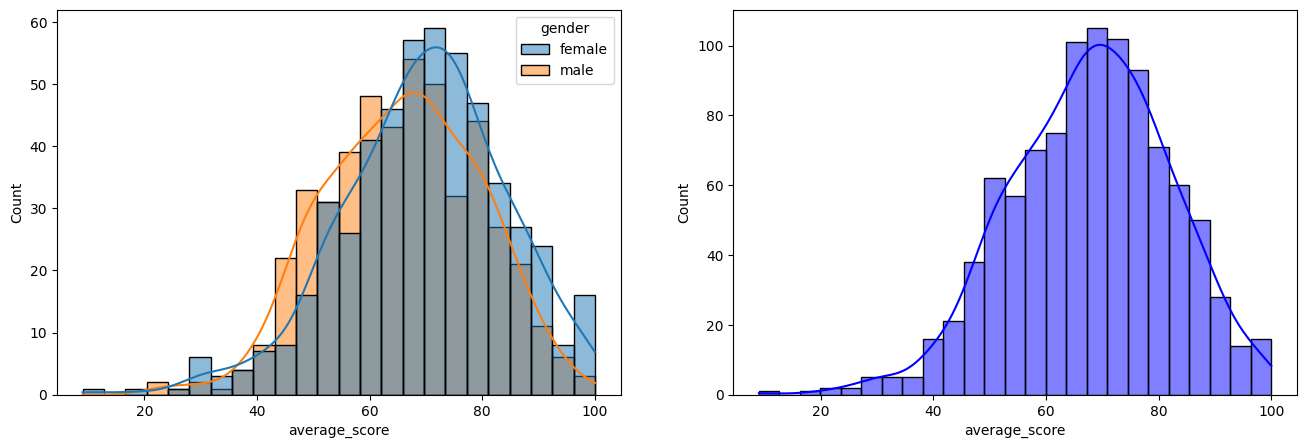

In [45]:
fig, axs = plt.subplots(1,2, figsize=(16,5))
plt.subplot(121)
sns.histplot(data=stud, x='average_score', hue='gender', kde=True)
plt.subplot(122)
sns.histplot(stud, x='average_score', kde=True, bins=25, color='b')
plt.show()

CREATE A HISTPLOT VISUALIZATION FOR TOTAL SCORE

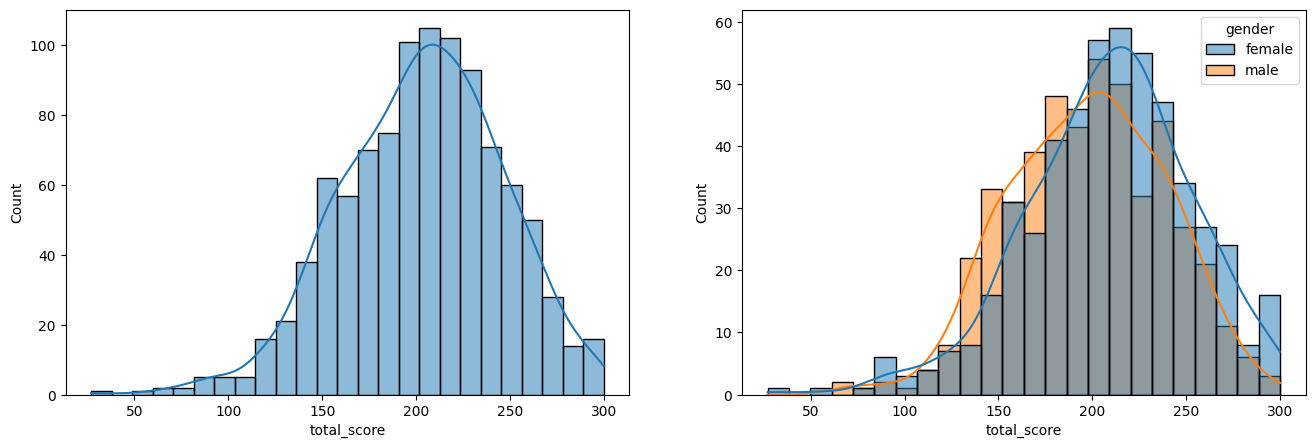

In [47]:
fig, axs = plt.subplots(1,2, figsize=(16,5))
plt.subplot(121)
sns.histplot(stud, x='total_score', kde=True, bins=25)
plt.subplot(122)
sns.histplot(stud, x='total_score', kde=True, hue='gender')
plt.show()

CREATING A HISTPLOT FOR AVERAGE SCORE AGAINST LUNCH

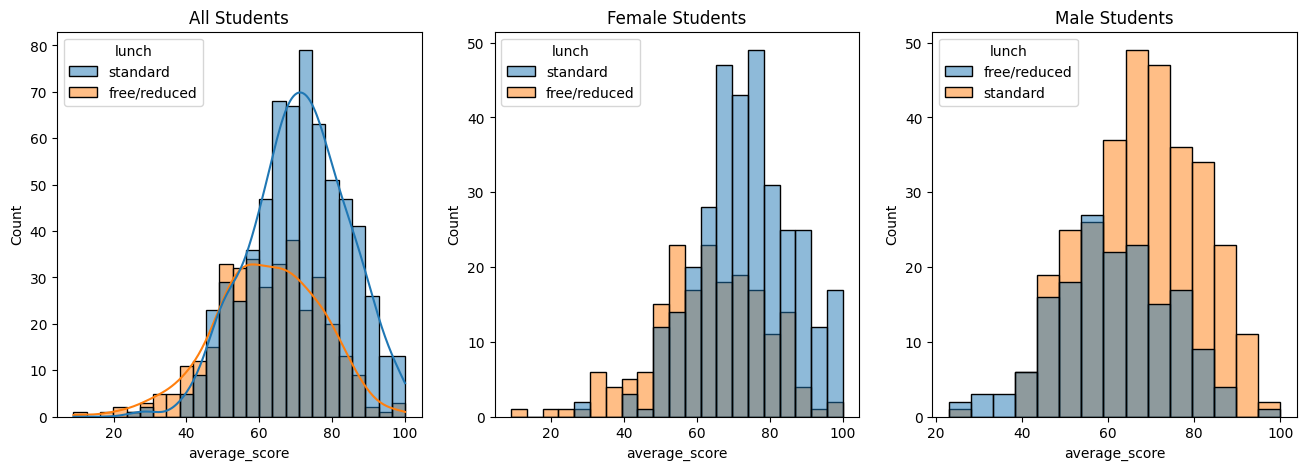

In [49]:
fig, axs = plt.subplots(1,3, figsize=(16,5))
plt.subplot(1,3,1)
plt.title("All Students")
sns.histplot(stud, x='average_score', kde=True, bins=25, hue='lunch')
plt.subplot(1,3,2)
plt.title('Female Students')
sns.histplot(stud[stud.gender=='female'], x='average_score', color='r', hue='lunch')
plt.subplot(1,3,3)
plt.title('Male Students')
sns.histplot(stud[stud.gender=='male'], x='average_score', color='g', hue='lunch')
plt.show()

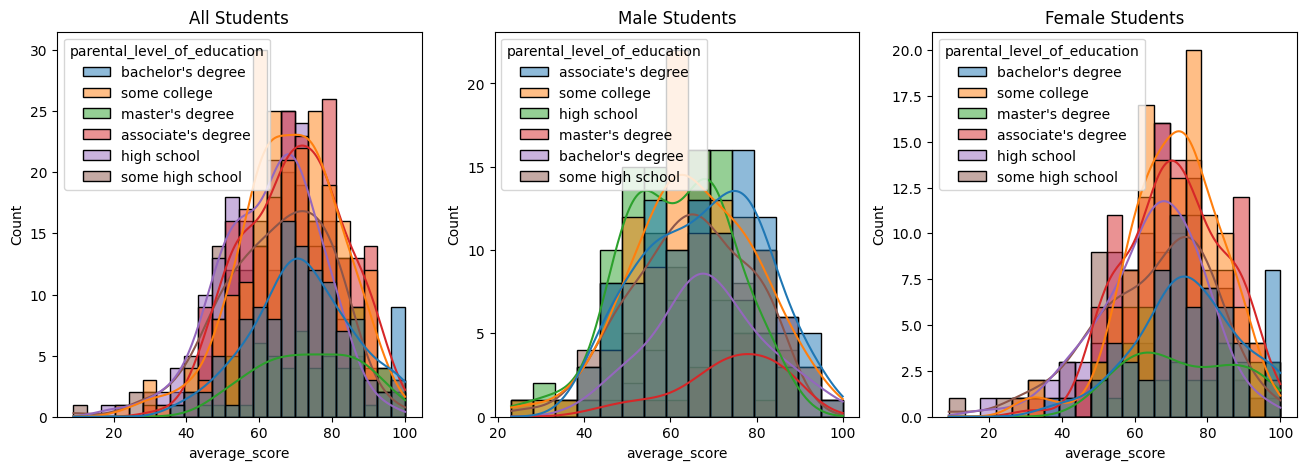

In [50]:
fig, axs = plt.subplots(1,3, figsize=(16,5))
plt.subplot(1,3,1)
plt.title('All Students')
sns.histplot(stud, x='average_score', kde=True, hue='parental_level_of_education')
plt.subplot(1,3,2)
plt.title('Male Students')
sns.histplot(stud[stud['gender']=='male'], x='average_score', kde=True, hue='parental_level_of_education')
plt.subplot(1,3,3)
plt.title('Female Students')
sns.histplot(stud[stud['gender']=='female'], x='average_score', kde=True, hue='parental_level_of_education')
plt.show()

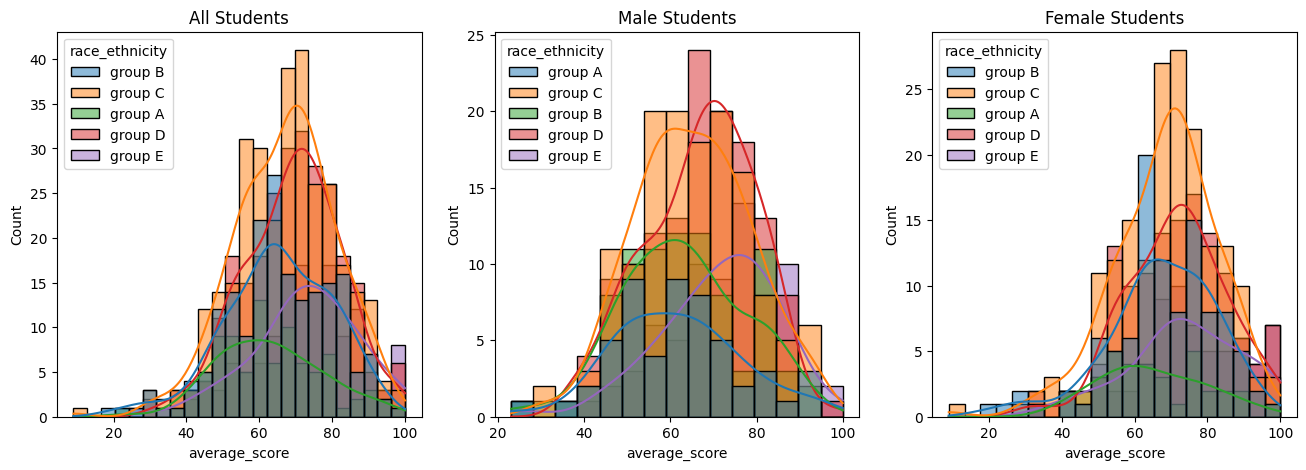

In [51]:
fig, axs = plt.subplots(1,3, figsize=(16,5))
plt.subplot(1,3,1)
plt.title('All Students')
sns.histplot(stud, x='average_score', kde=True, hue='race_ethnicity')
plt.subplot(1,3,2)
plt.title('Male Students')
sns.histplot(stud[stud['gender']=='male'], x='average_score', kde=True, hue='race_ethnicity')
plt.subplot(1,3,3)
plt.title('Female Students')
sns.histplot(stud[stud['gender']=='female'], x='average_score', kde=True, hue='race_ethnicity')
plt.show()

FINDING THE MAXIMUM AND MINIMUM SCORE OF STUDENTS IN ALL SUBJECTS
- Using Violin plot

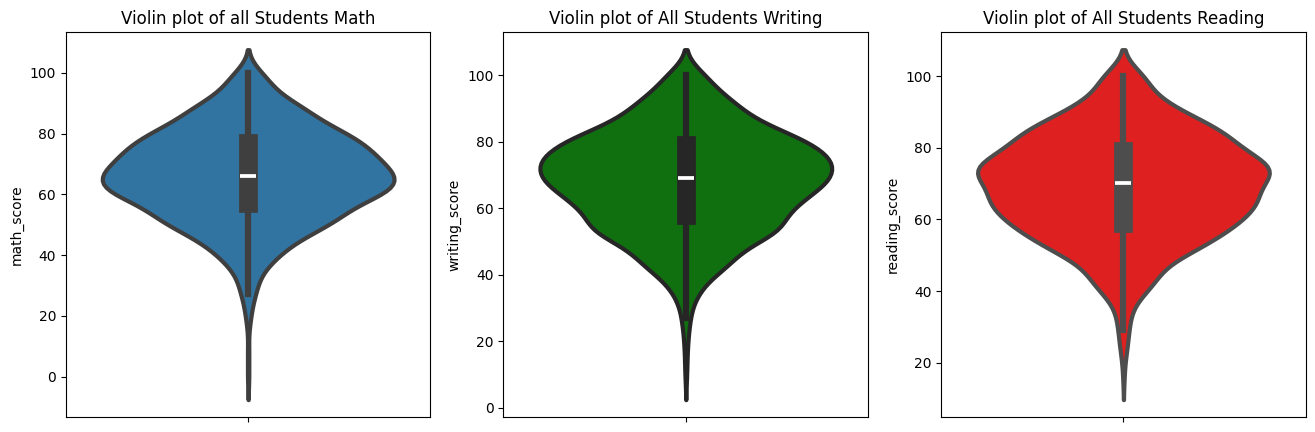

In [53]:
fig, axs=plt.subplots(1,3, figsize=(16,5))
plt.subplot(1,3,1)
plt.title('Violin plot of all Students Math')
sns.violinplot(data=stud, y='math_score', linewidth=3)
plt.subplot(1,3,2)
plt.title('Violin plot of All Students Writing')
sns.violinplot(stud, y='writing_score', linewidth=3, color='g')
plt.subplot(1,3,3)
plt.title('Violin plot of All Students Reading')
sns.violinplot(stud, y='reading_score', linewidth=3, color='r')
plt.show()

DOING MULTIVARIATE ANALYSIS USING PIE CHART PLOT

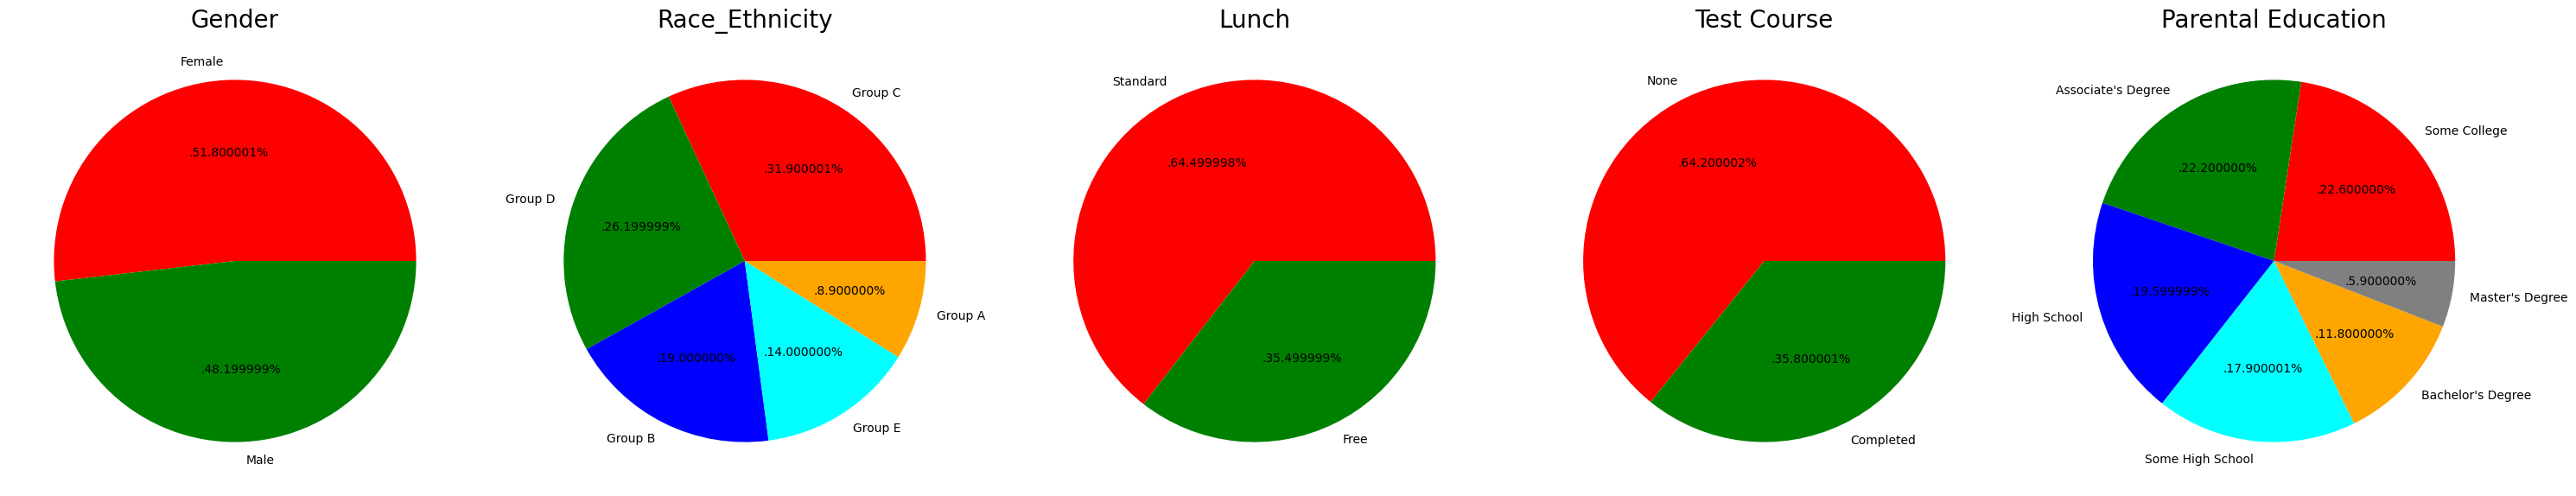

In [55]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = stud['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')

plt.subplot(1, 5, 2)
size = stud['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = stud['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = stud['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = stud['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

DOING A UNIVARIATE ANALYSIS USING COUNT PLOT AND PIE CHART PLOT

In [57]:
stud['gender'].value_counts()

gender
female    518
male      482
Name: count, dtype: int64

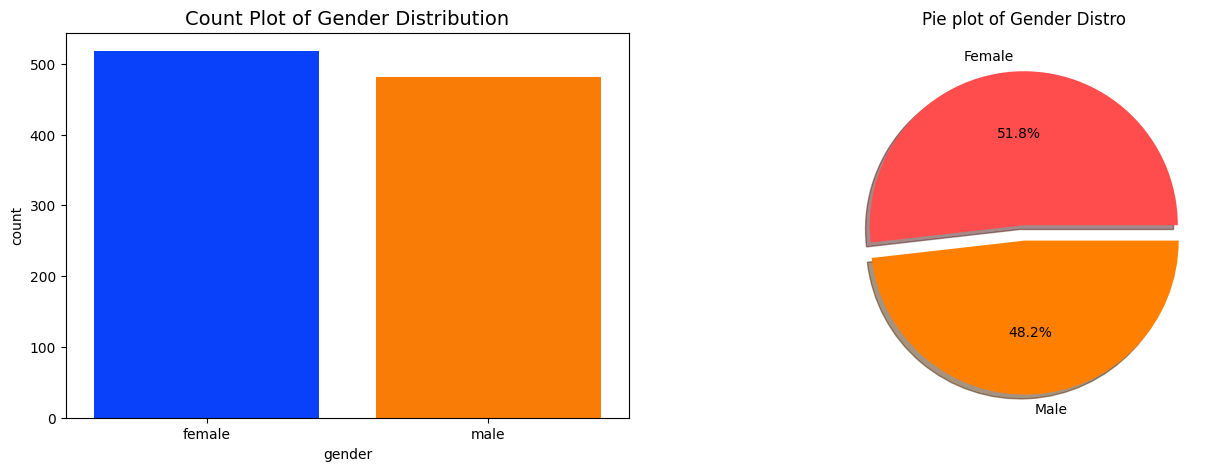

In [58]:
f,ax=plt.subplots(1,2,figsize=(16,5))


sns.countplot(stud, x='gender', palette='bright', ax=ax[0],saturation=0.95, hue='gender')
ax[0].set_title('Count Plot of Gender Distribution', fontsize=14)

plt.title('Pie plot of Gender Distro')
plt.pie(x=stud['gender'].value_counts(), labels=['Female', 'Male'], explode=[0,0.1],autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'])


plt.show()

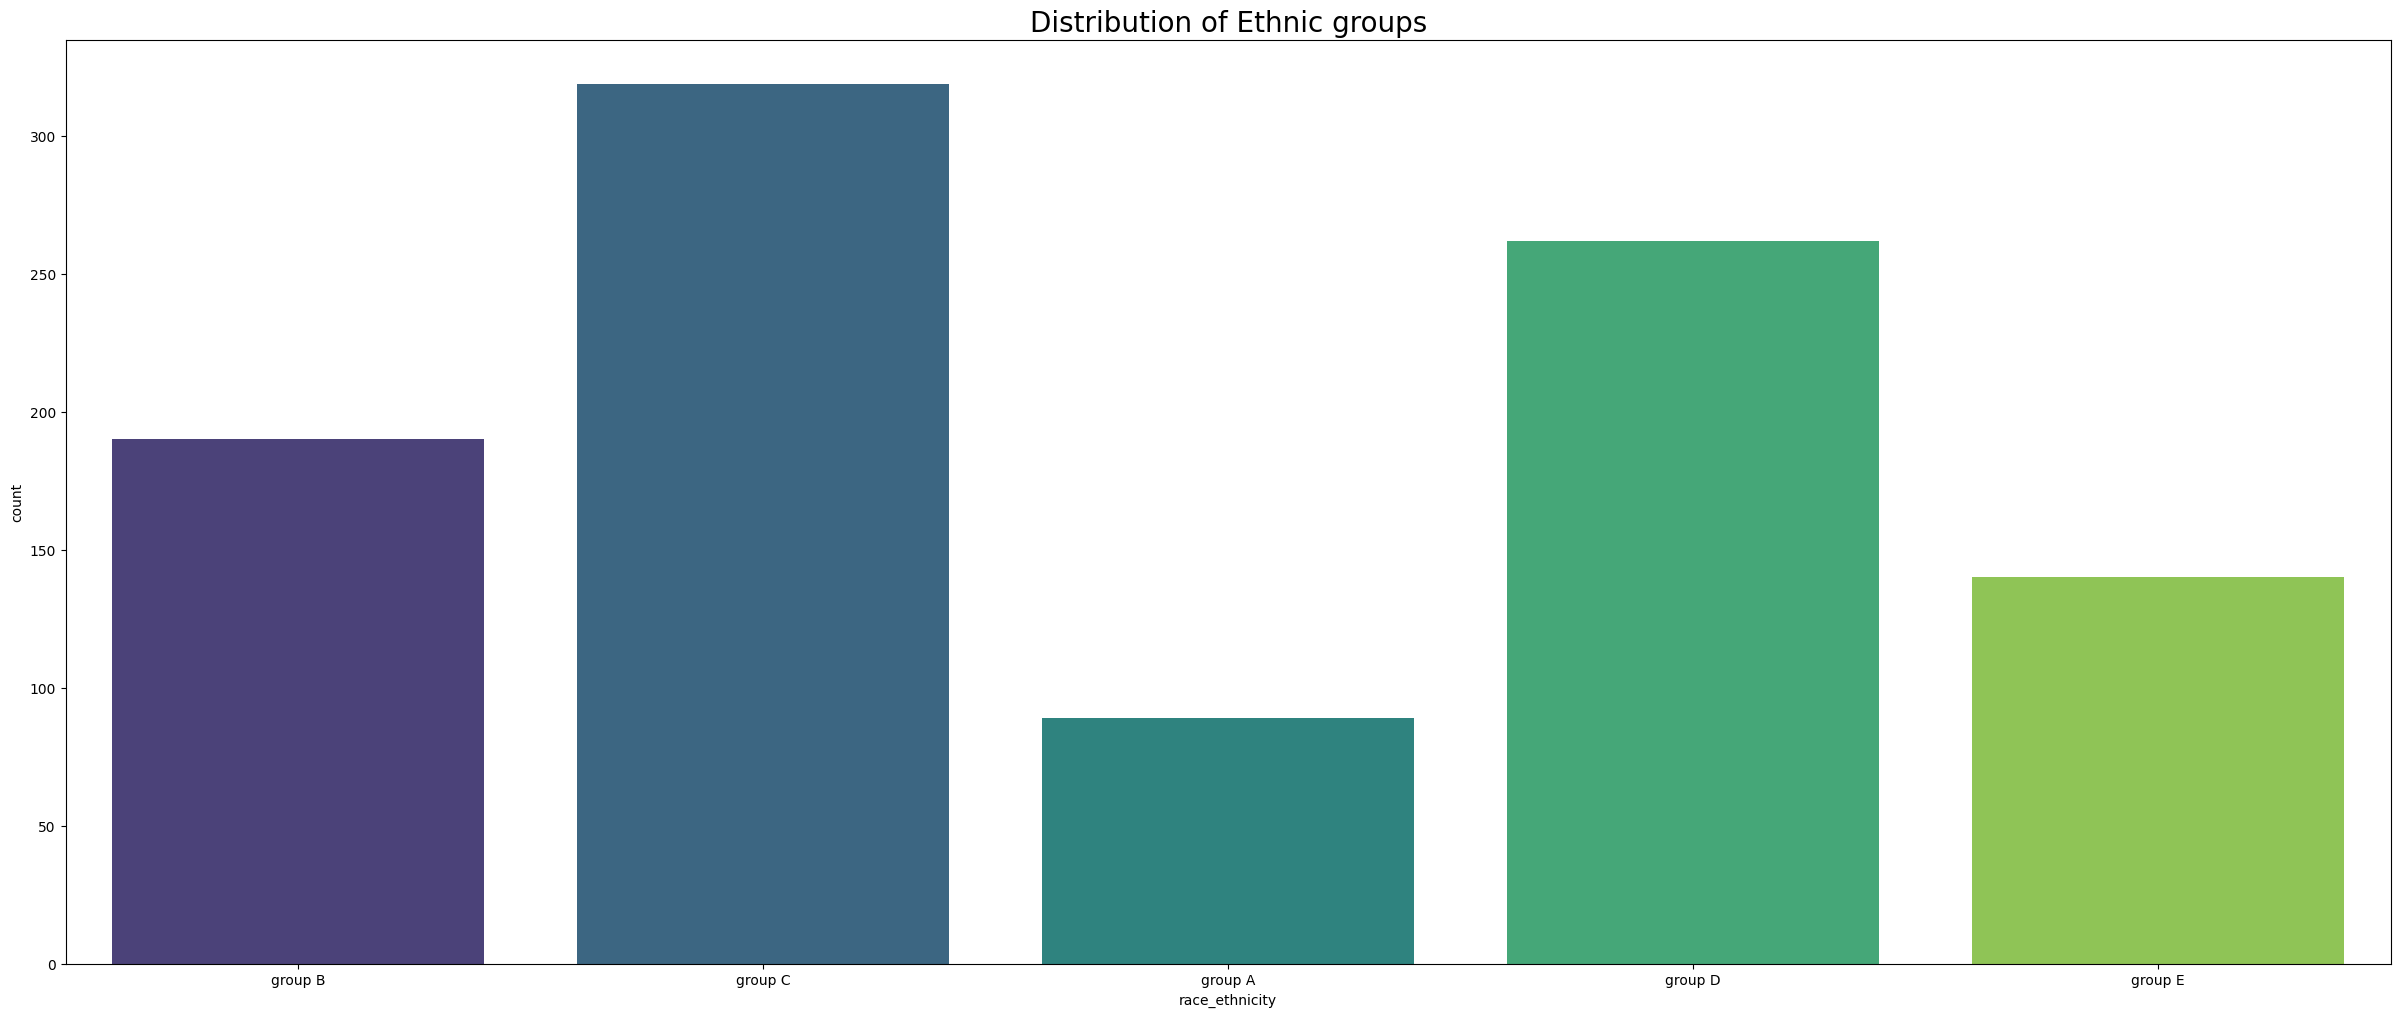

In [59]:
figsize=(12,5)
plt.title('Distribution of Ethnic groups', fontsize=20)
sns.countplot(stud, x='race_ethnicity', palette='viridis', hue='race_ethnicity')
plt.show()

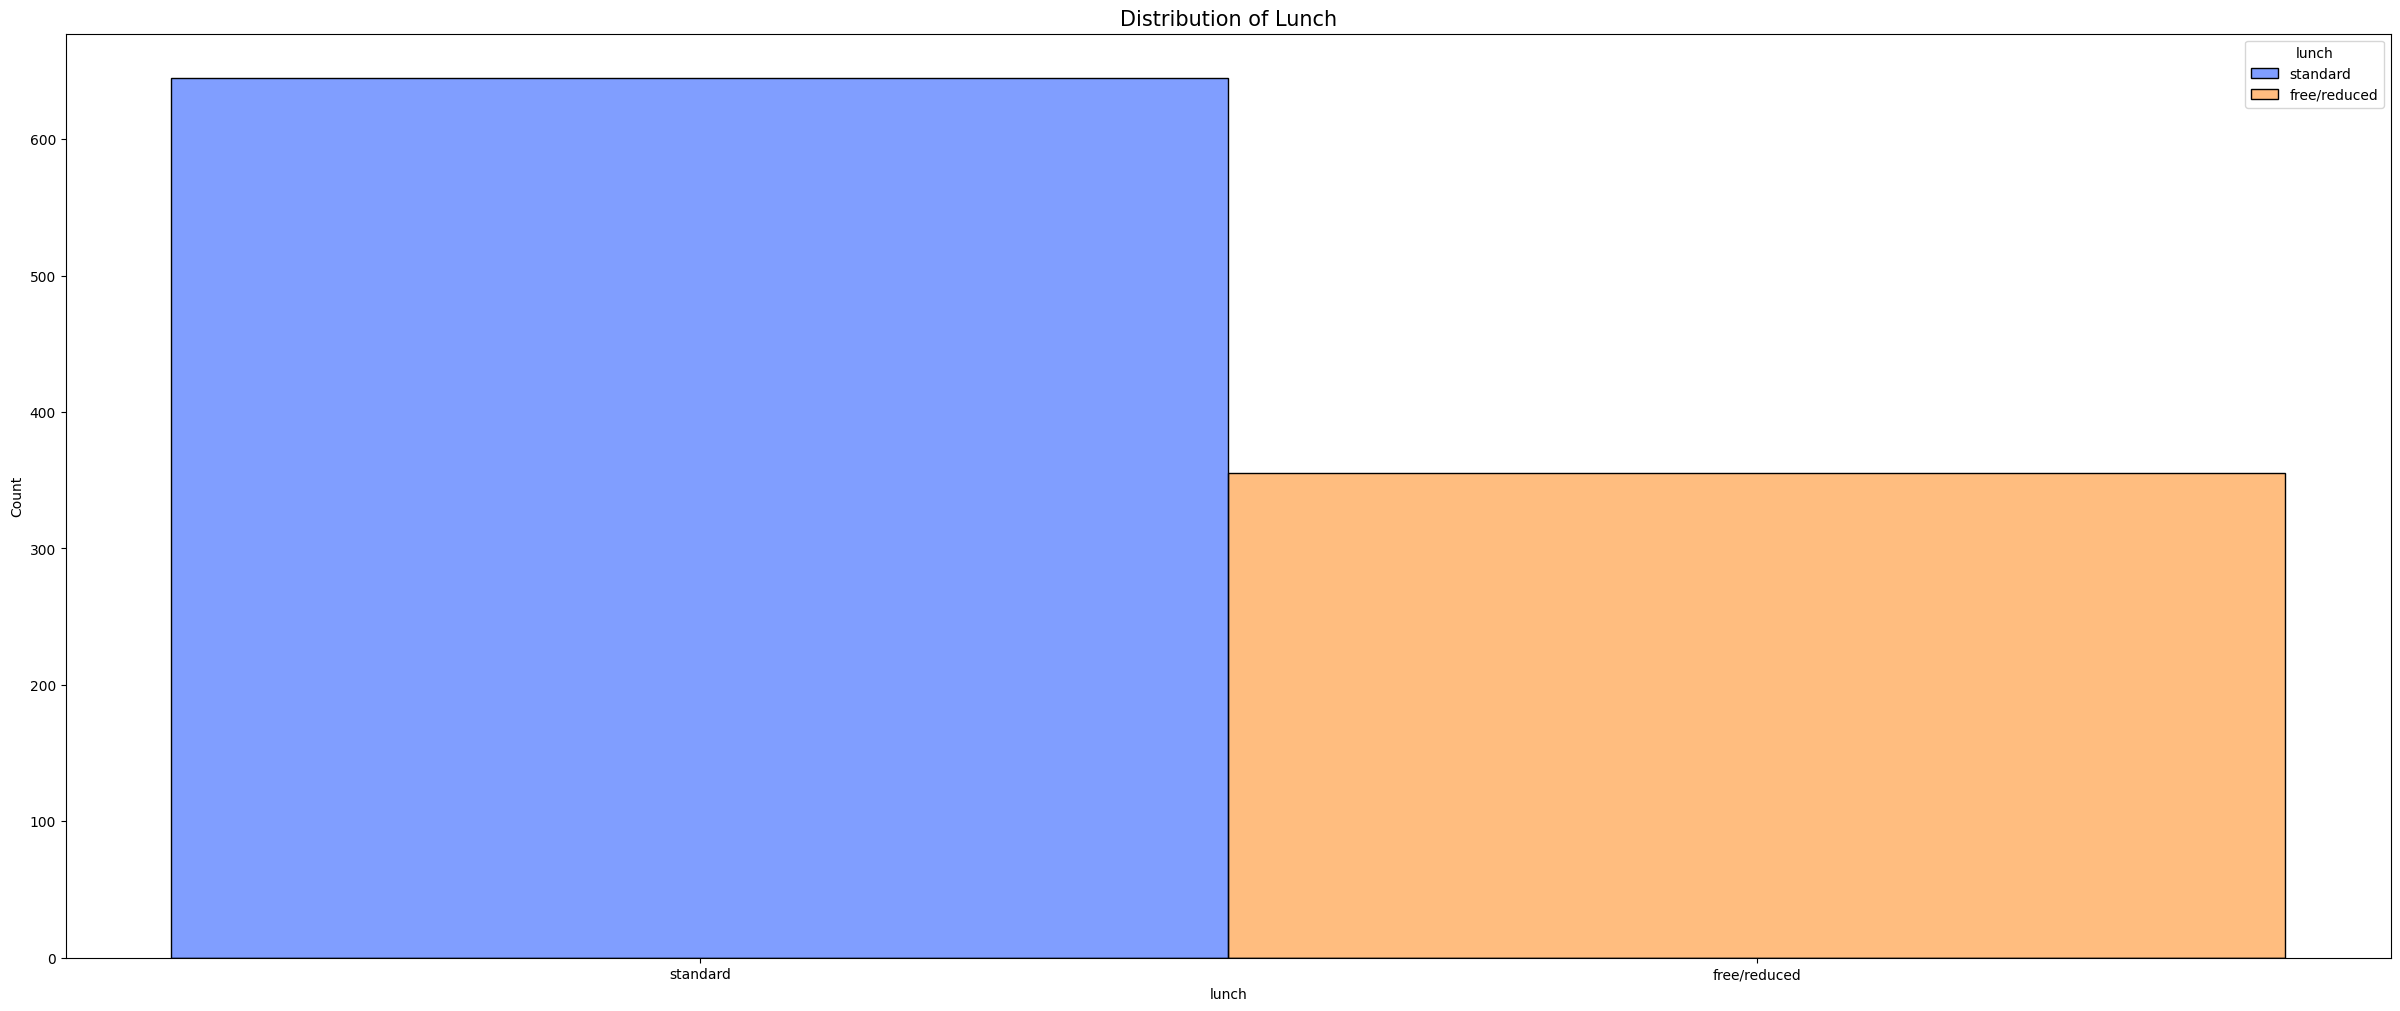

In [60]:
figsize=(8,5)
plt.title('Distribution of Lunch', fontsize=15)
sns.histplot(stud, x='lunch', palette='bright', hue='lunch')
plt.show()

C:\Users\Durosimi\AppData\Local\Temp\ipykernel_13400\368188766.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(stud['lunch'], palette = 'PuBu')


<Axes: xlabel='count', ylabel='lunch'>

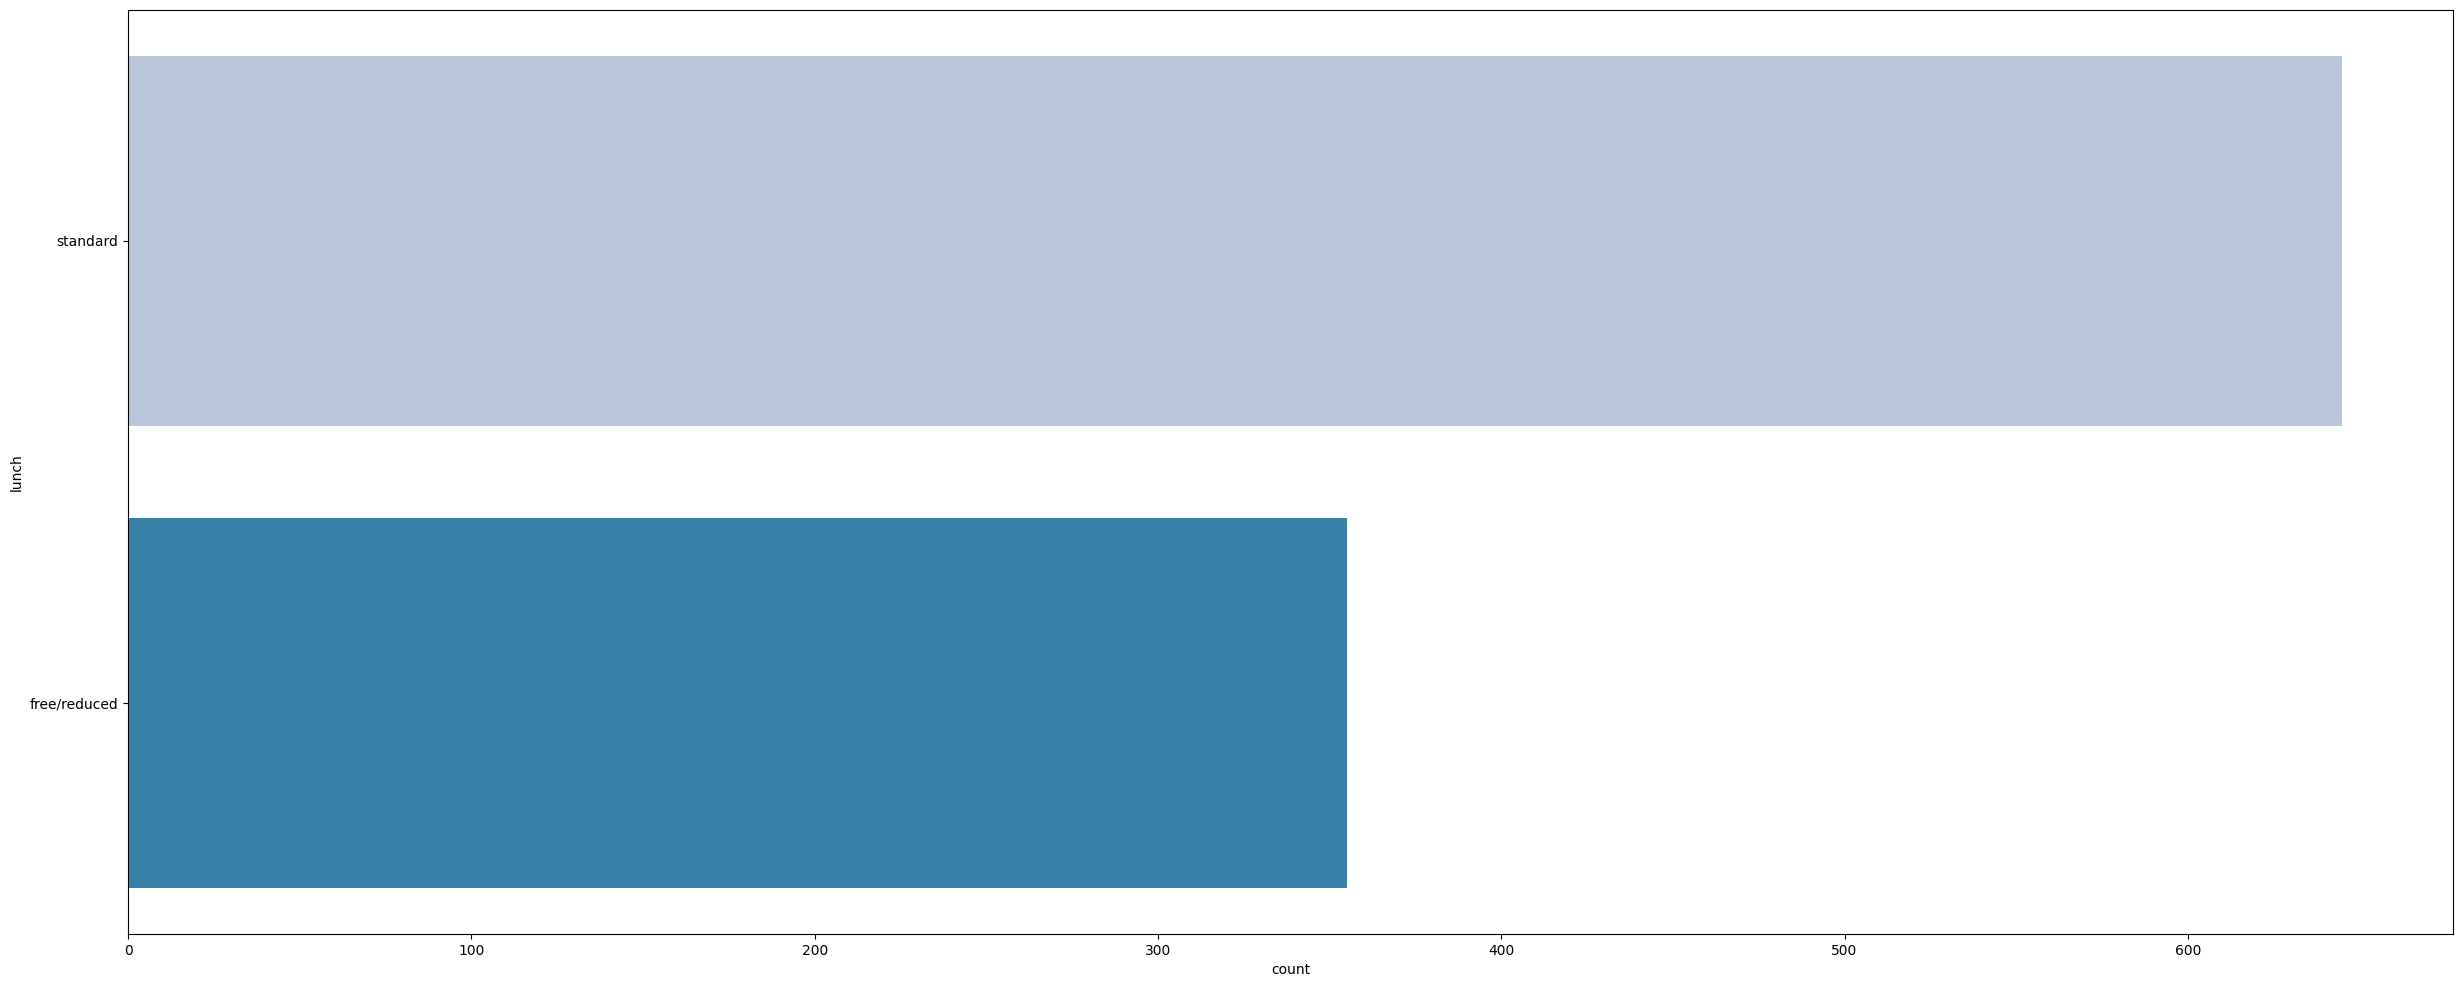

In [61]:
sns.countplot(stud['lunch'], palette = 'PuBu')

DOING BIVARIATE ANALYSIS ON THE FEATURES
- GENDER
- RACE
- TOTAL SCORES
- INDIVIDUAL SCORES

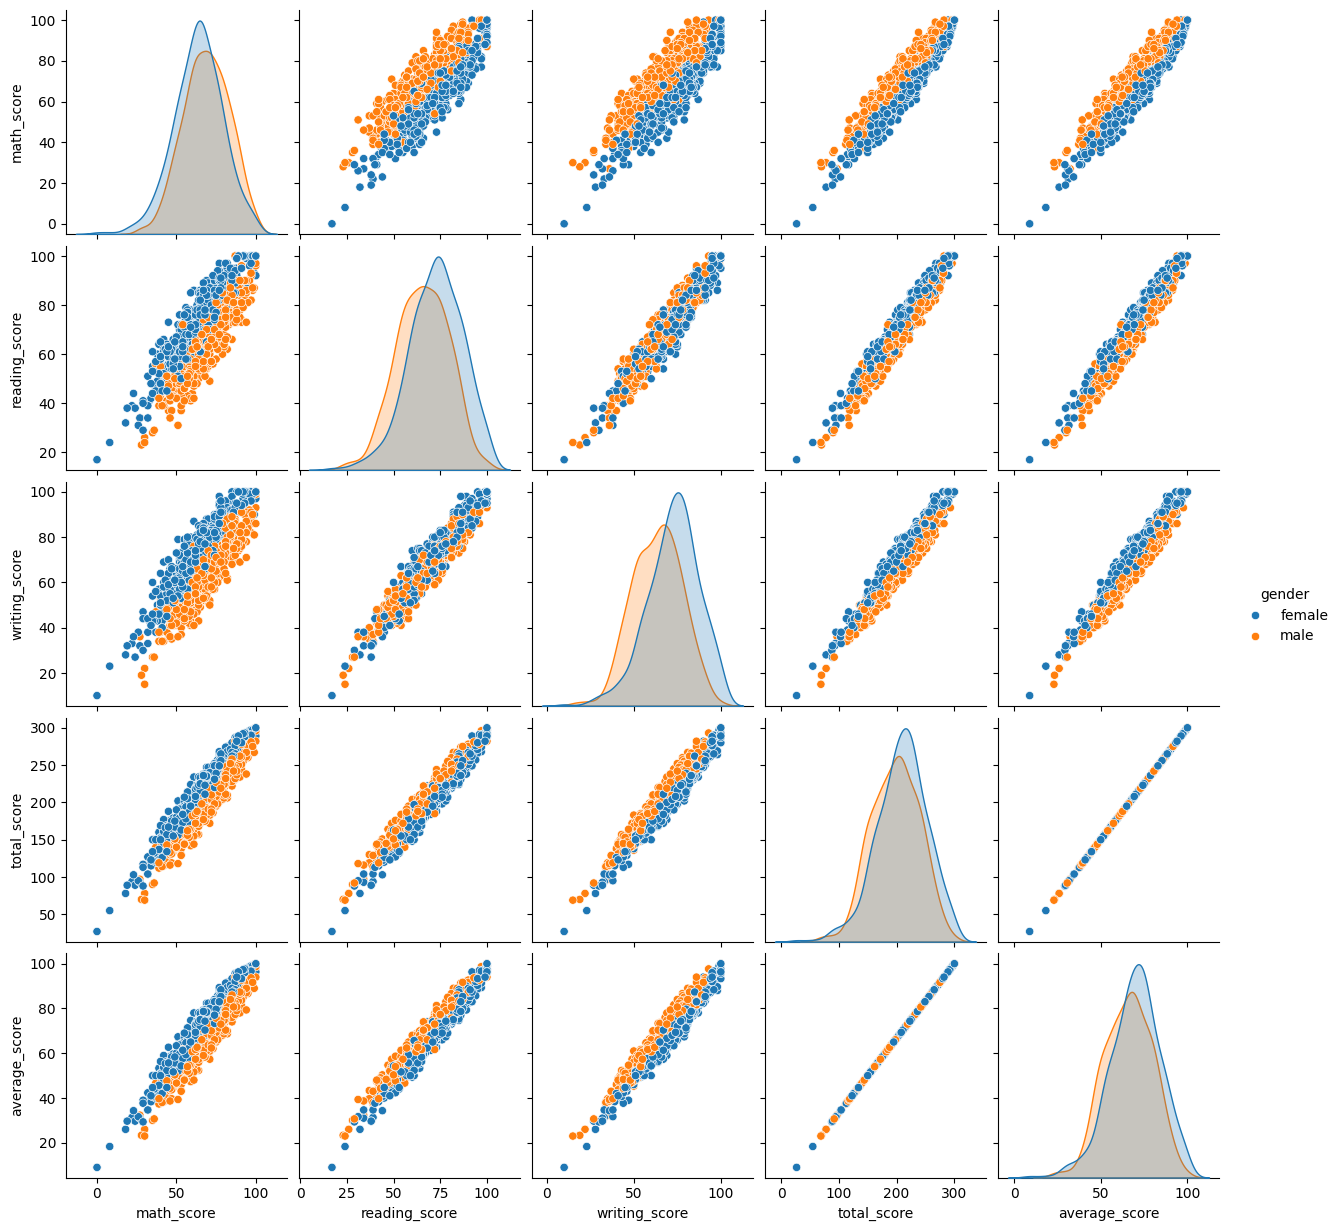

In [63]:

sns.pairplot(stud, hue='gender')
plt.show()

<Axes: title={'center': 'Students vs Parental Education '}, xlabel='parental_level_of_education', ylabel='count'>

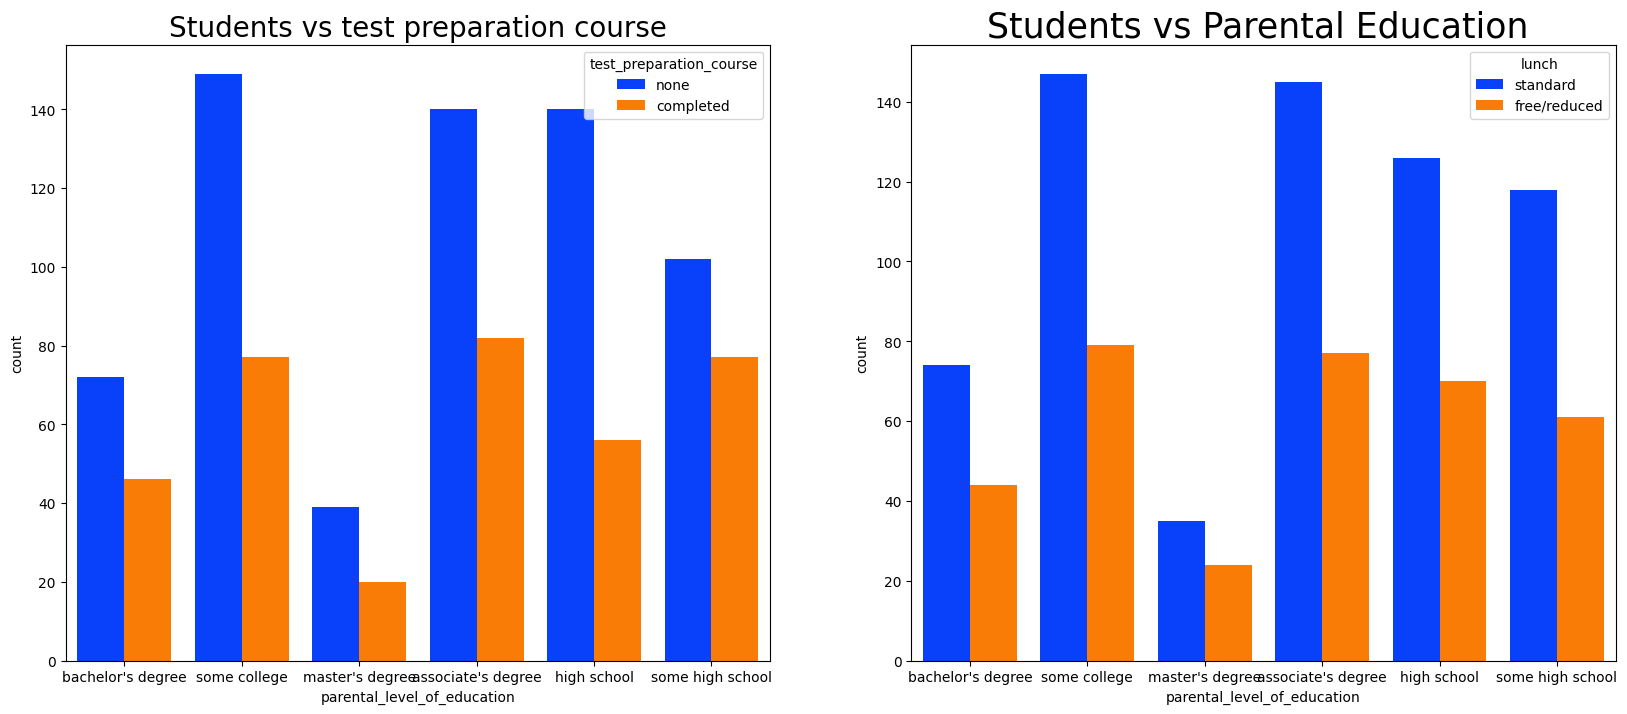

In [64]:
f,ax=plt.subplots(1,2,figsize=(20,8))
ax[0].set_title('Students vs test preparation course', fontsize=20)
sns.countplot(x=stud['parental_level_of_education'],data=stud,palette = 'bright',hue='test_preparation_course',saturation=0.95,ax=ax[0])
plt.title('Students vs Parental Education ',color='black',size=25)
sns.countplot(x=stud['parental_level_of_education'],data=stud,palette = 'bright',hue='lunch',saturation=0.95,ax=ax[1])

<Axes: xlabel='average_score', ylabel='total_score'>

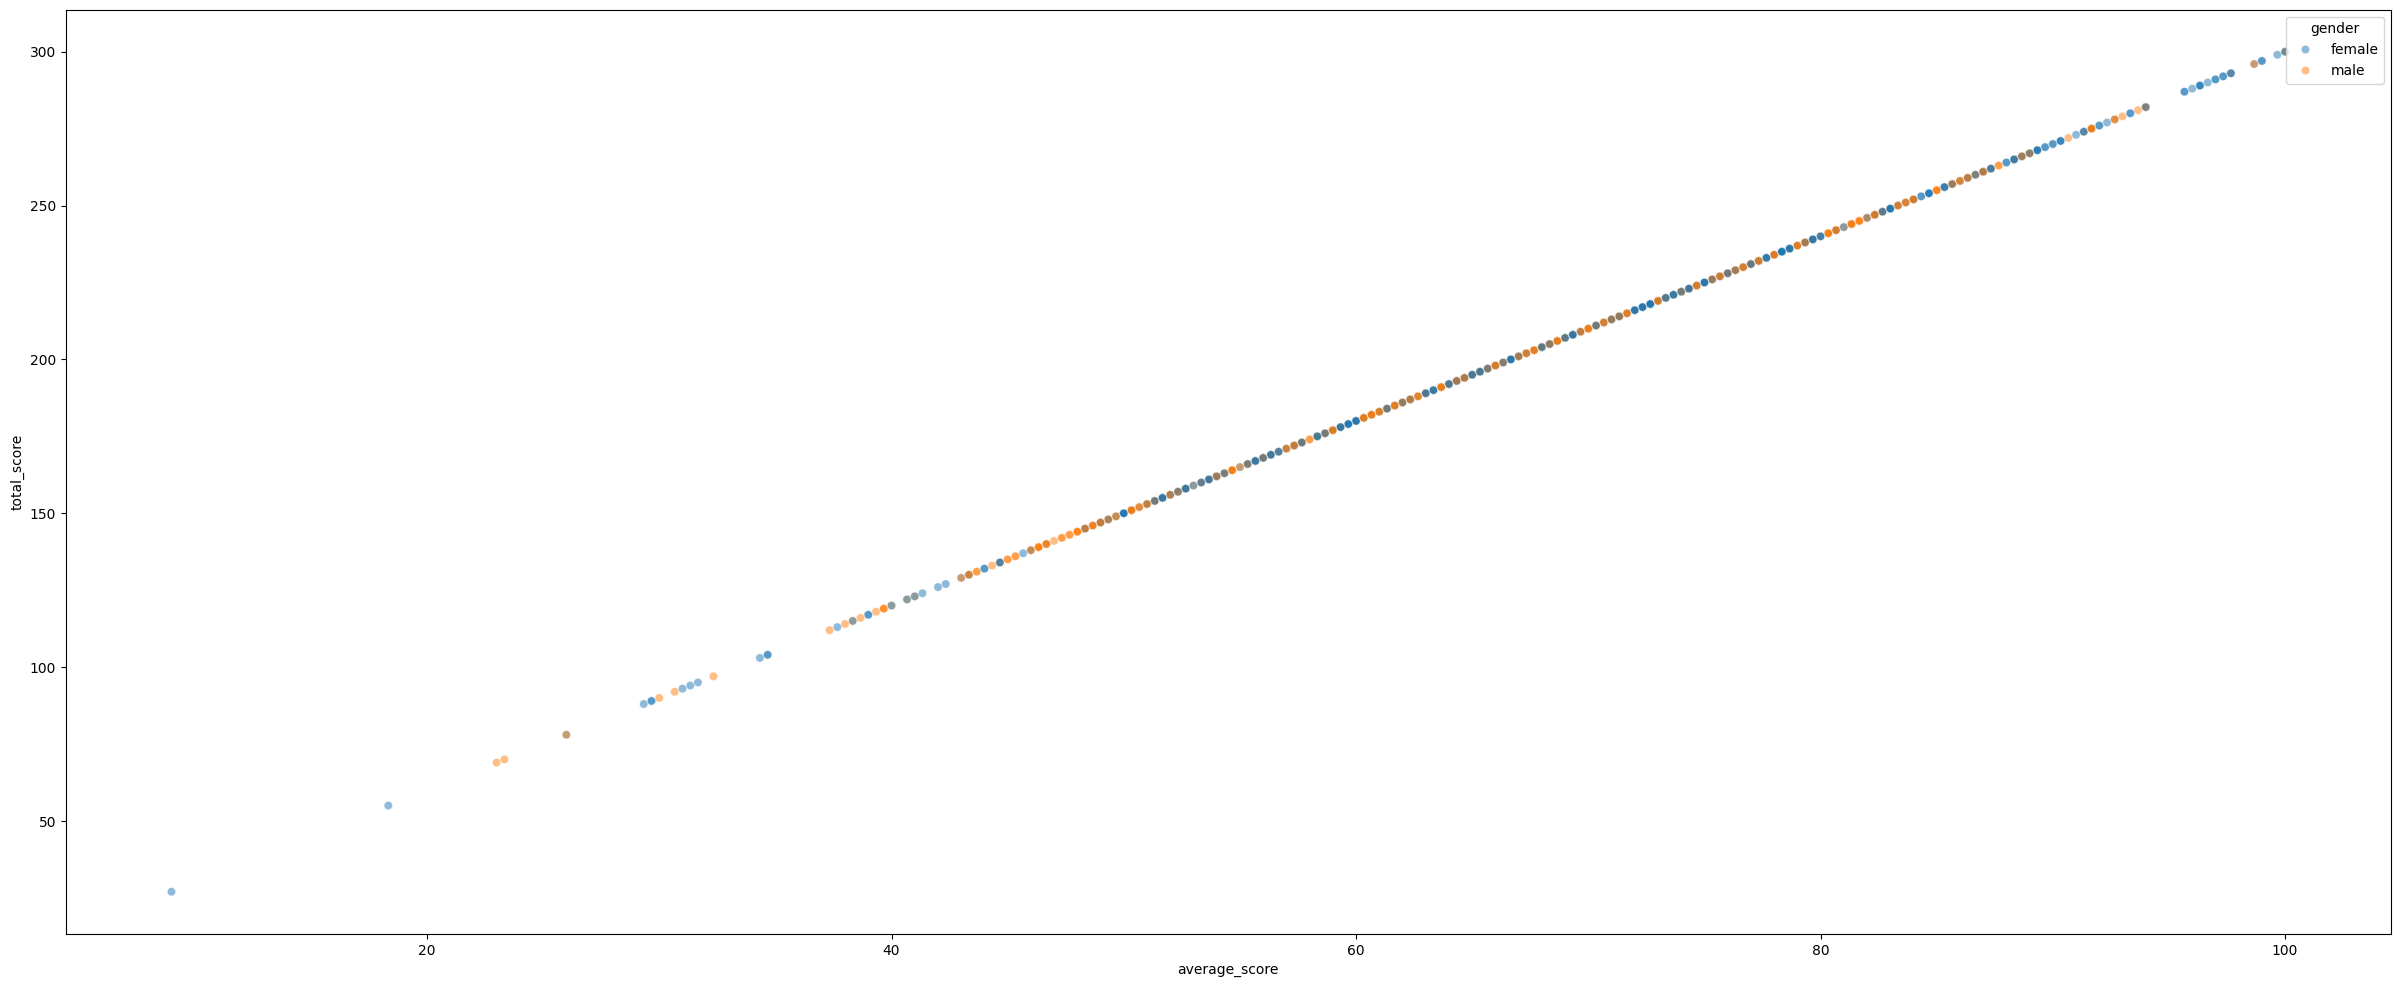

In [65]:
figsize=(4,3)
sns.scatterplot(stud, x='average_score', y='total_score', alpha=0.5, hue='gender')

<Axes: xlabel='average_score', ylabel='total_score'>

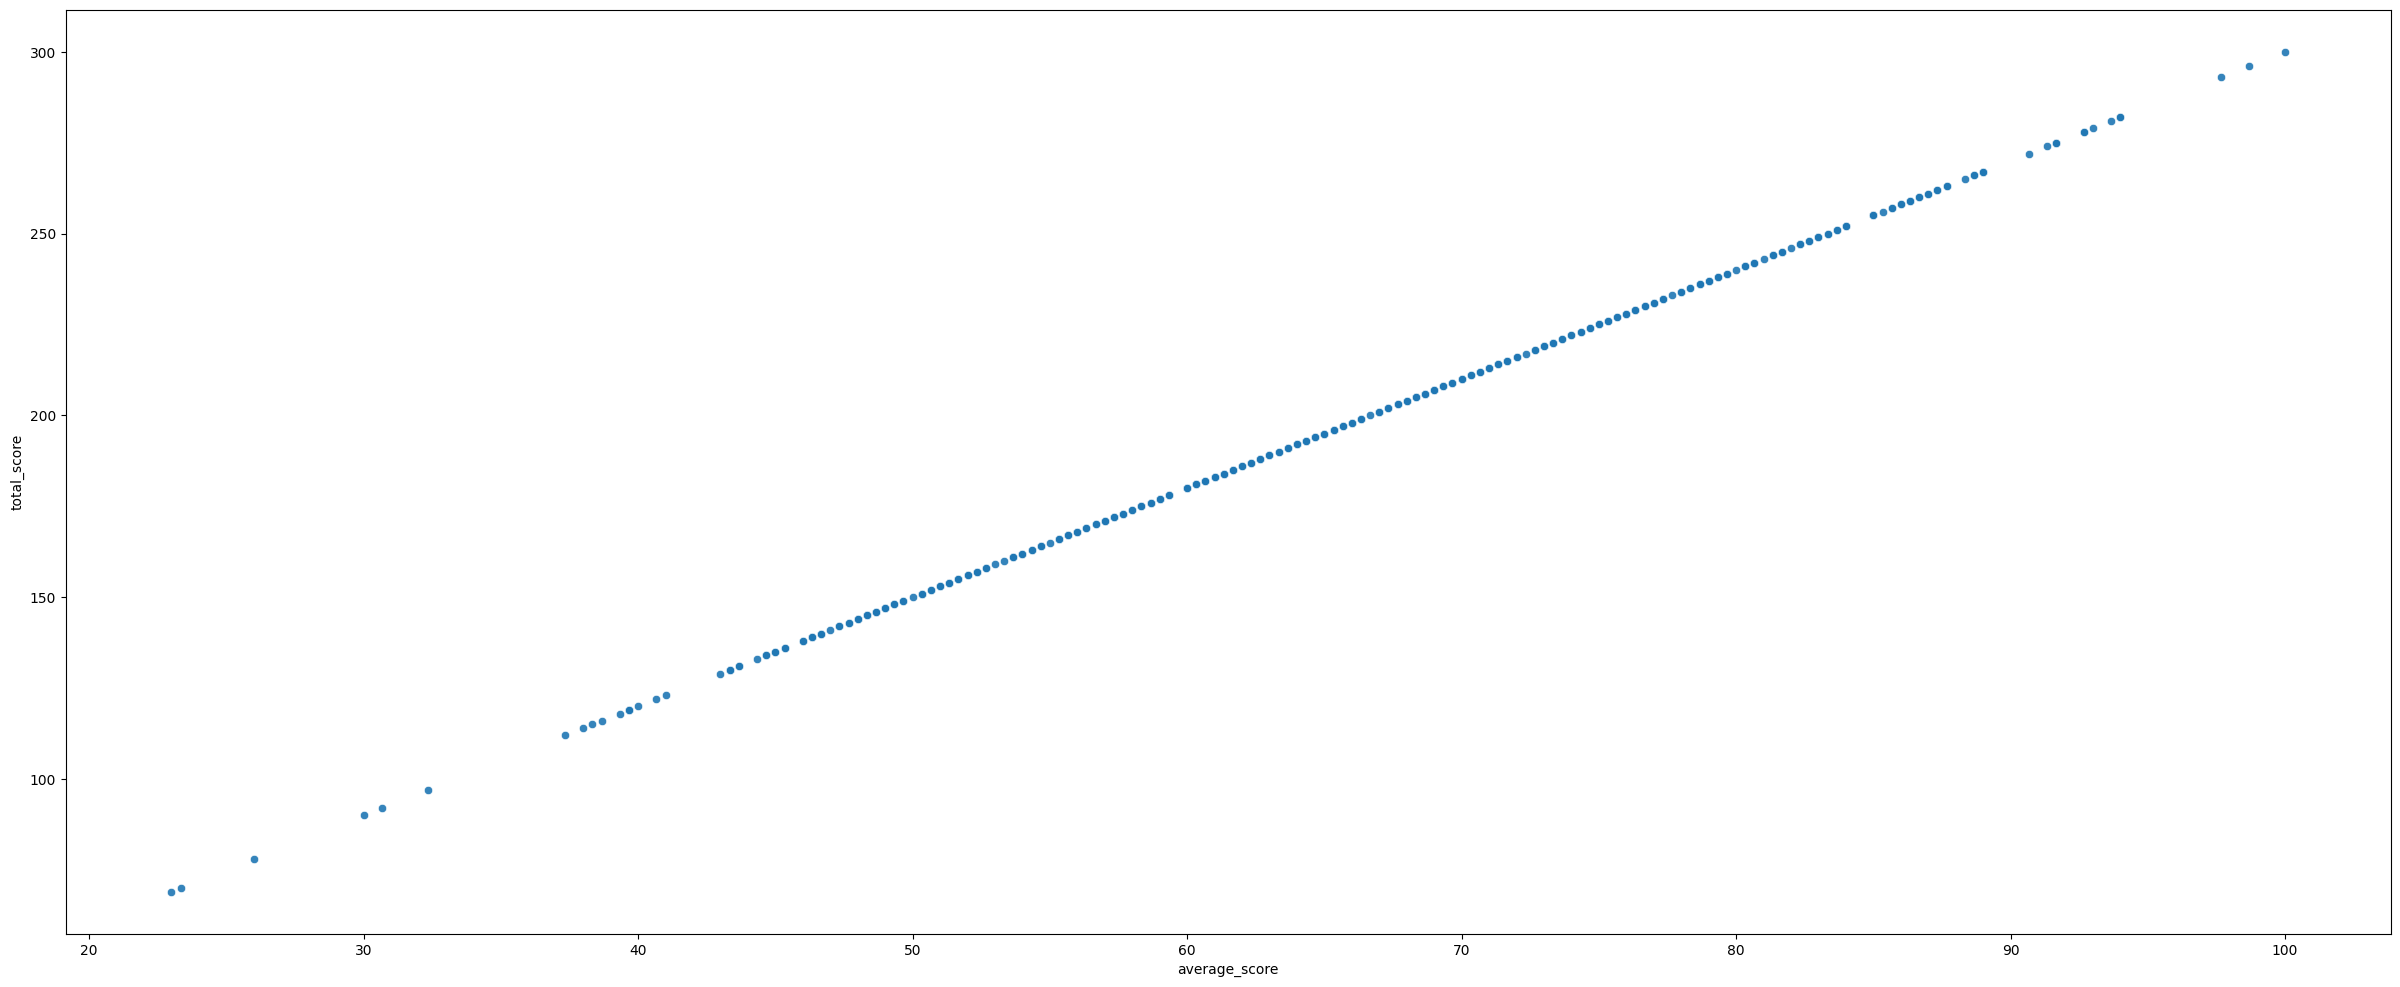

In [66]:
figsize=(4,3)
sns.scatterplot(stud[stud['gender']=='male'], x='average_score', y='total_score', alpha=0.9)

<Axes: xlabel='average_score', ylabel='total_score'>

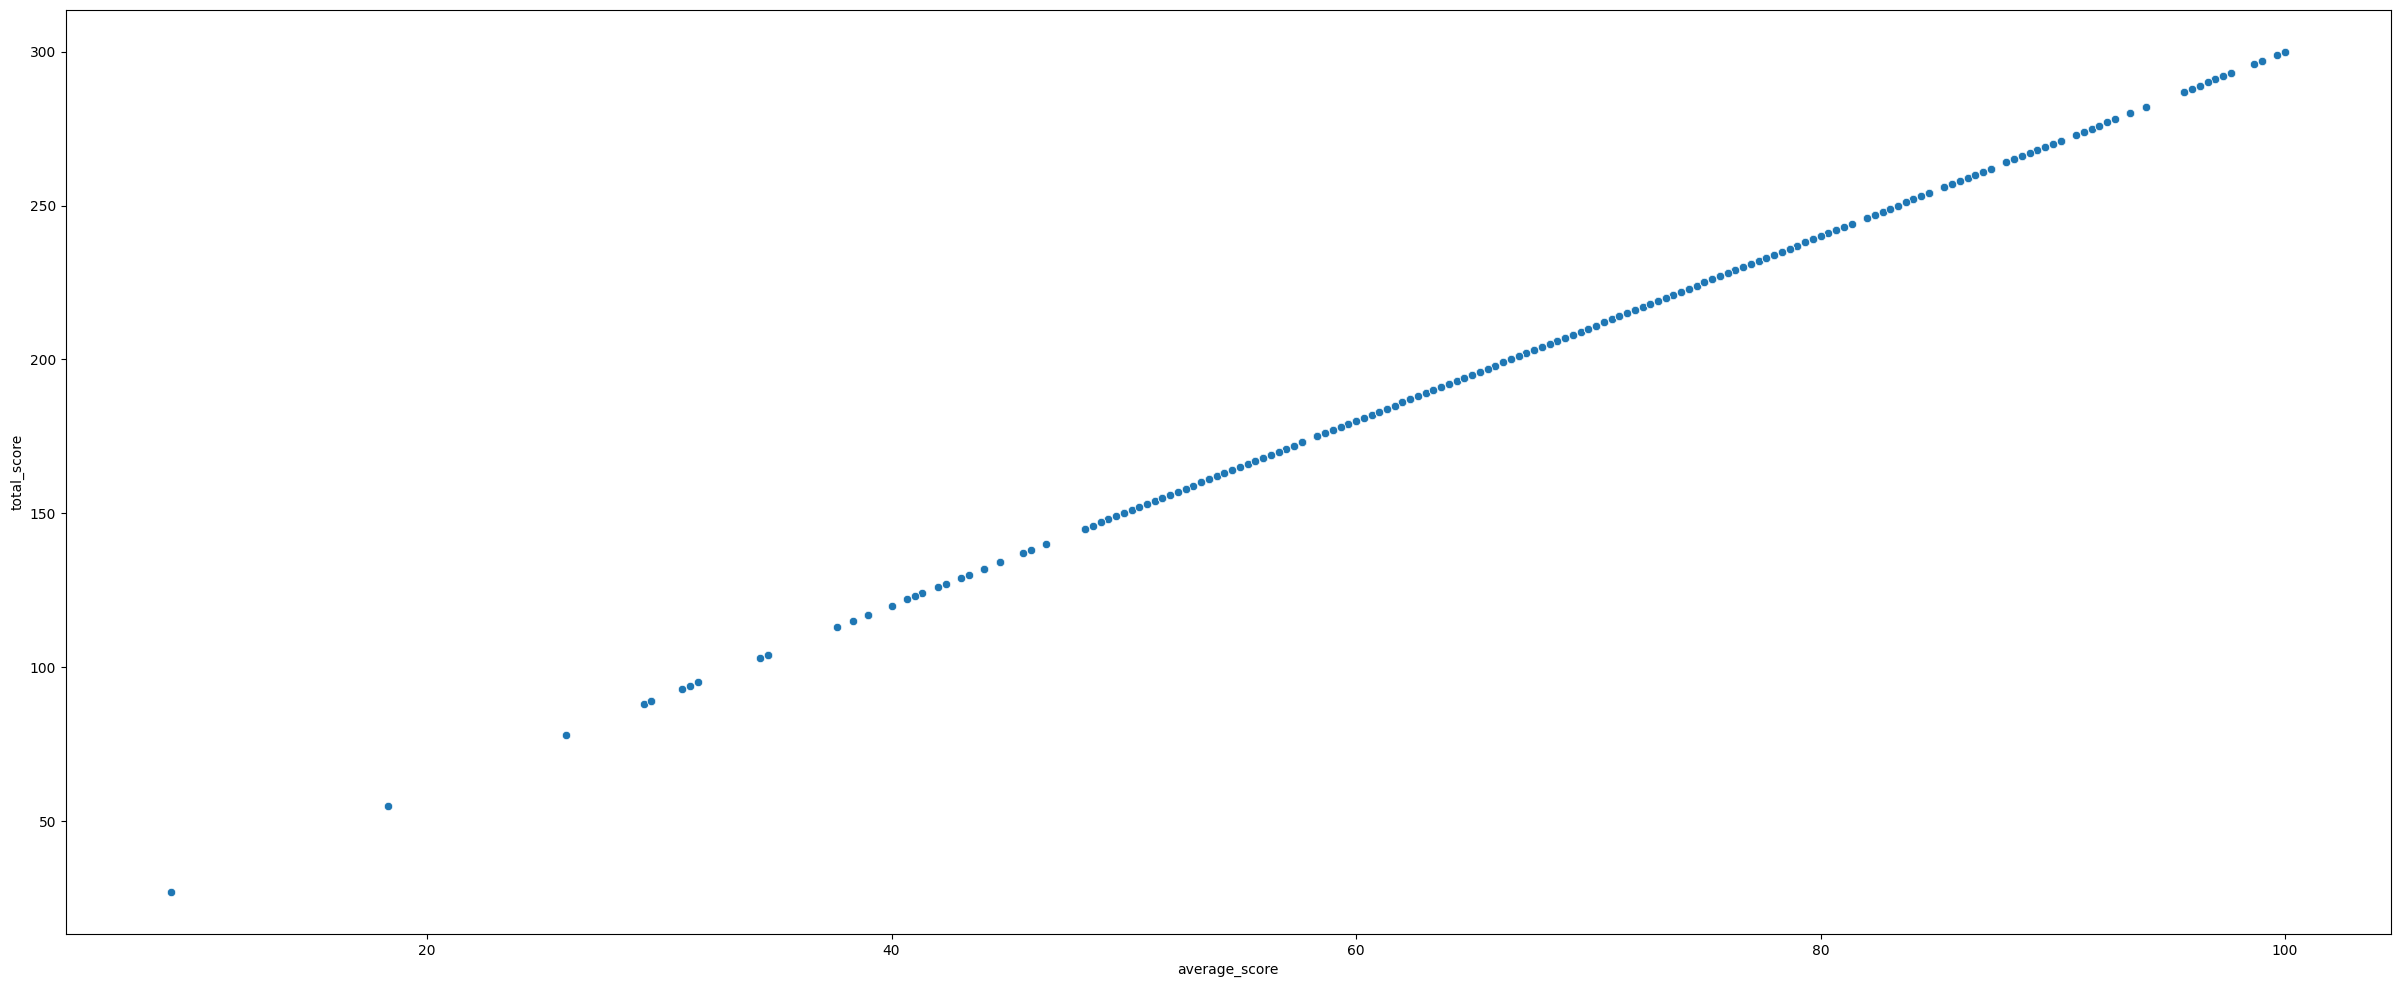

In [67]:
sns.scatterplot(stud[stud['gender']== 'female'], x='average_score', y='total_score')

DOES ETHNICITY AFFECT STUDENTS SCORES?

C:\Users\Durosimi\AppData\Local\Temp\ipykernel_13400\333877653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0],)
C:\Users\Durosimi\AppData\Local\Temp\ipykernel_13400\333877653.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
C:\Users\Durosimi\AppData\Local\Temp\ipykernel_13400\333877653.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the s

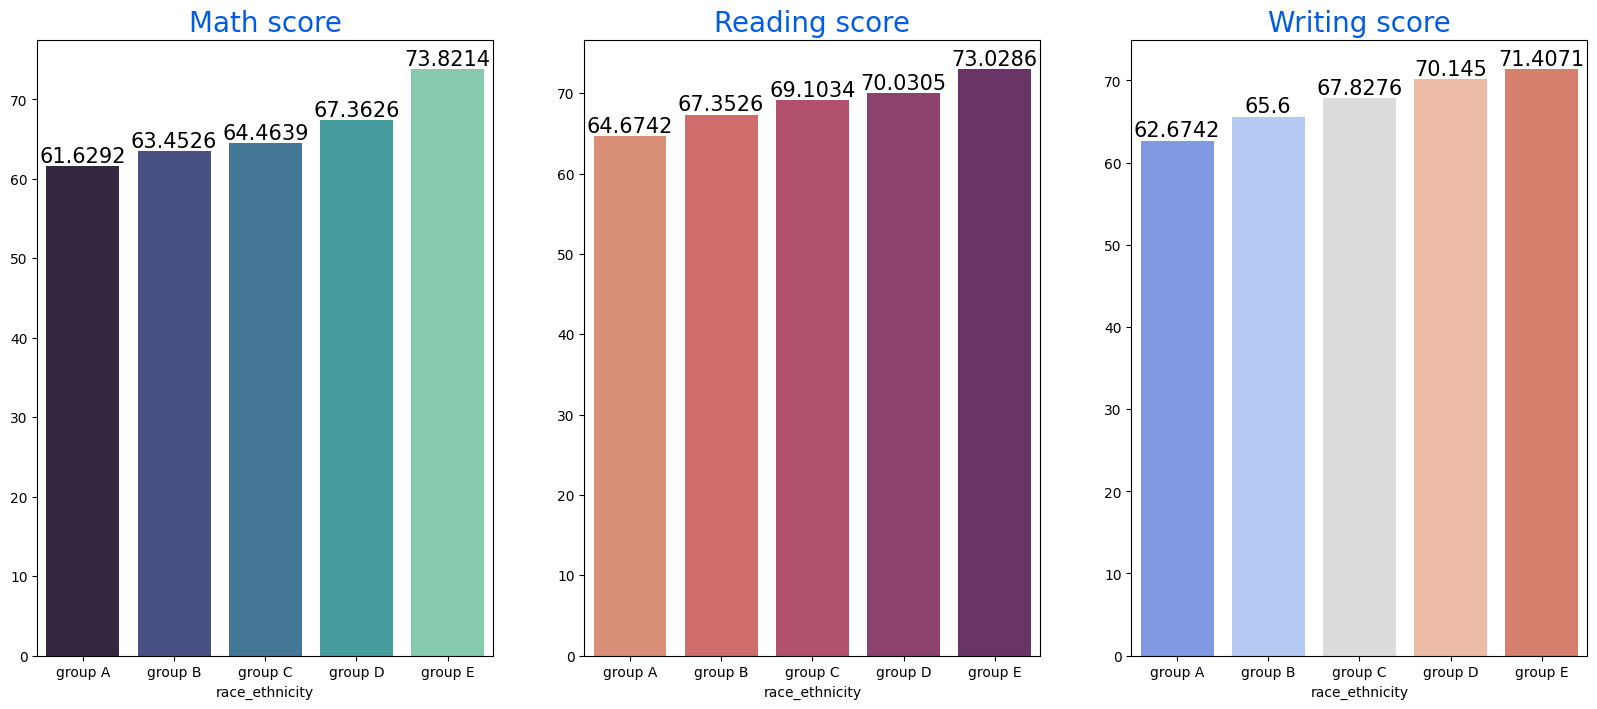

In [69]:
Group_data2=stud.groupby('race_ethnicity')
f,ax=plt.subplots(1,3,figsize=(20,8))
sns.barplot(x=Group_data2['math_score'].mean().index,y=Group_data2['math_score'].mean().values,palette = 'mako',ax=ax[0],)
ax[0].set_title('Math score',color='#005ce6',size=20)

for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['reading_score'].mean().index,y=Group_data2['reading_score'].mean().values,palette = 'flare',ax=ax[1])
ax[1].set_title('Reading score',color='#005ce6',size=20)

for container in ax[1].containers:
    ax[1].bar_label(container,color='black',size=15)

sns.barplot(x=Group_data2['writing_score'].mean().index,y=Group_data2['writing_score'].mean().values,palette = 'coolwarm',ax=ax[2])
ax[2].set_title('Writing score',color='#005ce6',size=20)

for container in ax[2].containers:
    ax[2].bar_label(container,color='black',size=15)

CHECKING FOR OUTLIERS USING BOXPLOT

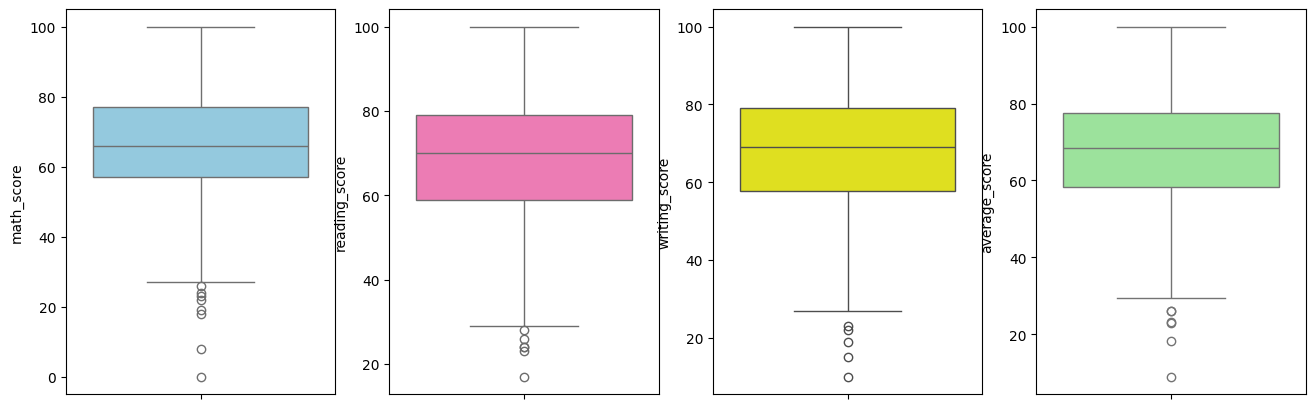

In [71]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(stud['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(stud['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(stud['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(stud['average_score'],color='lightgreen')
plt.show()

MODEL TRAINING


- Split the data into X and Y
- Do OneHot Encoding or LabelEncoder on features that are not in 0 or 1 format
- 

In [134]:
stud.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [136]:
X = stud.drop(['math_score'], axis=1)

In [140]:
y = stud['math_score']

In [146]:
X.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,74,218,72.666667
1,female,group C,some college,standard,completed,90,88,247,82.333333
2,female,group B,master's degree,standard,none,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,57,44,148,49.333333
4,male,group C,some college,standard,none,78,75,229,76.333333


In [148]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [150]:
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

In [155]:
X = preprocessor.fit_transform(X)

In [163]:
X.shape

(1000, 21)

In [174]:
from sklearn.model_selection import train_test_split

In [176]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42 )

Create Evaluation function for all metrics after model training

In [219]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true,predicted)

    return mae, rmse, r2_square

In [231]:
np.allclose(y_test, y_test_pred)

False

In [207]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [221]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor":XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "Ada Boost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list = []
## TRAINING THE MODEL
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

## MAKING PREDICTIONS
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

# EVALUATING THE TRAIN AND TEST DATASET
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print('Model performance for trainig set')
    print("- Root Mean Squared Error: {: .4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {: 4f}".format(model_train_mae))

    print("---------------------------------------------------")
    print('Model performance for Test set')
    print("Root Mean Squared Error: {: .4f}".format(model_test_rmse))
    print("Mean Absolute Error: {: .4f}".format(model_test_mae))
    print("R2 Score: {: .4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for trainig set
- Root Mean Squared Error:  0.0000
- Mean Absolute Error:  0.000000
---------------------------------------------------
Model performance for Test set
Root Mean Squared Error:  0.0000
Mean Absolute Error:  0.0000
R2 Score:  1.0000


Lasso
Model performance for trainig set
- Root Mean Squared Error:  4.7381
- Mean Absolute Error:  3.743857
---------------------------------------------------
Model performance for Test set
Root Mean Squared Error:  4.7171
Mean Absolute Error:  3.7579
R2 Score:  0.9086


Ridge
Model performance for trainig set
- Root Mean Squared Error:  0.3396
- Mean Absolute Error:  0.272441
---------------------------------------------------
Model performance for Test set
Root Mean Squared Error:  0.3432
Mean Absolute Error:  0.2684
R2 Score:  0.9995


K-Neighbors Regressor
Model performance for trainig set
- Root Mean Squared Error:  4.2791
- Mean Absolute Error:  3.383750
---------------------------------------------

In [238]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', "R2_Score"]).sort_values(by=["R2_Score"], ascending=False)

,Model Name,R2_Score
0,Linear Regression,1.000000
2,Ridge,0.999516
6,XGBRegressor,0.977101
7,CatBoosting Regressor,0.968100
5,Random Forest Regressor,0.960869
4,Decision Tree,0.933364
8,Ada Boost Regressor,0.925790
1,Lasso,0.908560
3,K-Neighbors Regressor,0.889781


LINEAR REGRESSION

In [242]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the model is %.2f" %score)

Accuracy of the model is 100.00


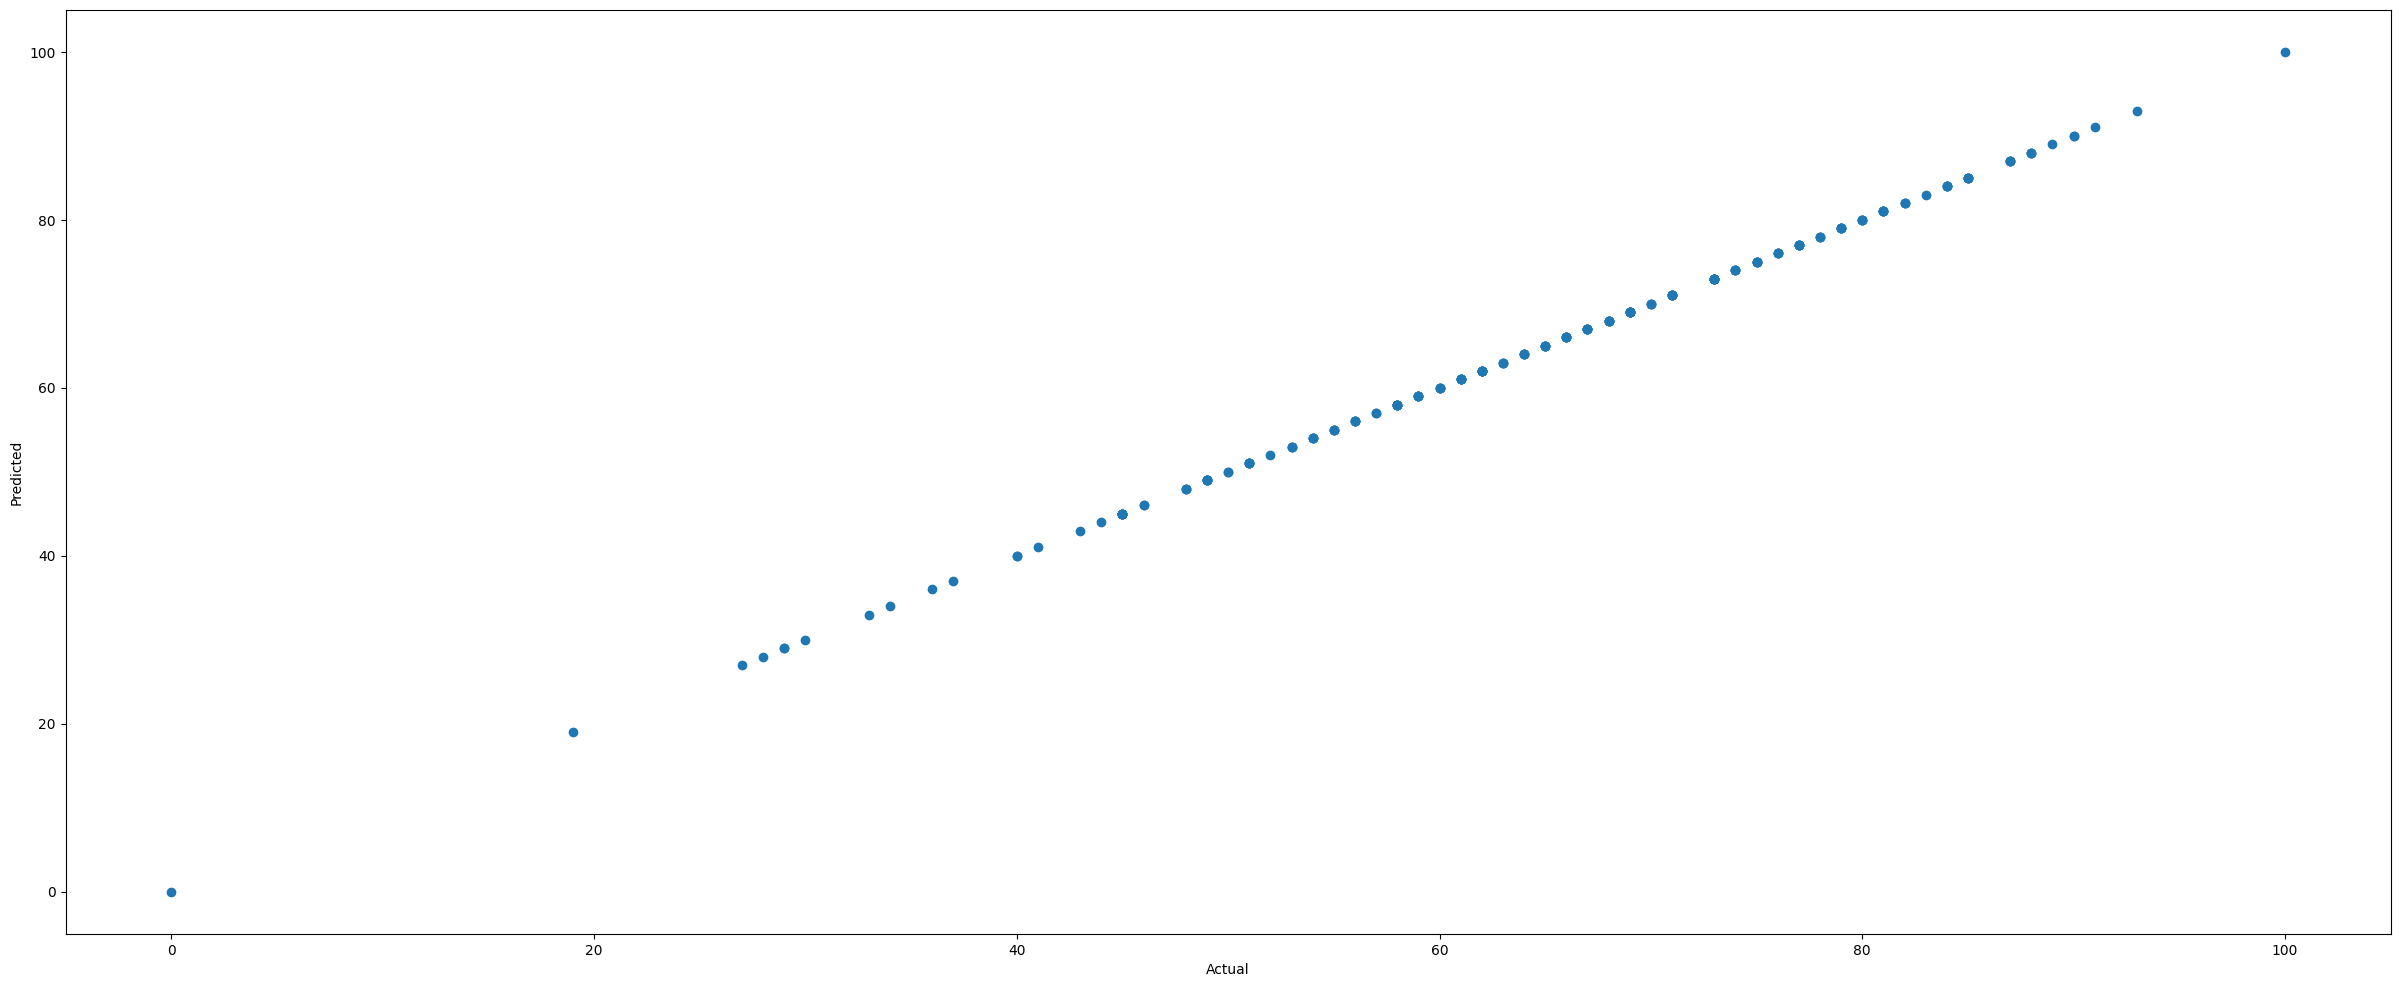

In [246]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

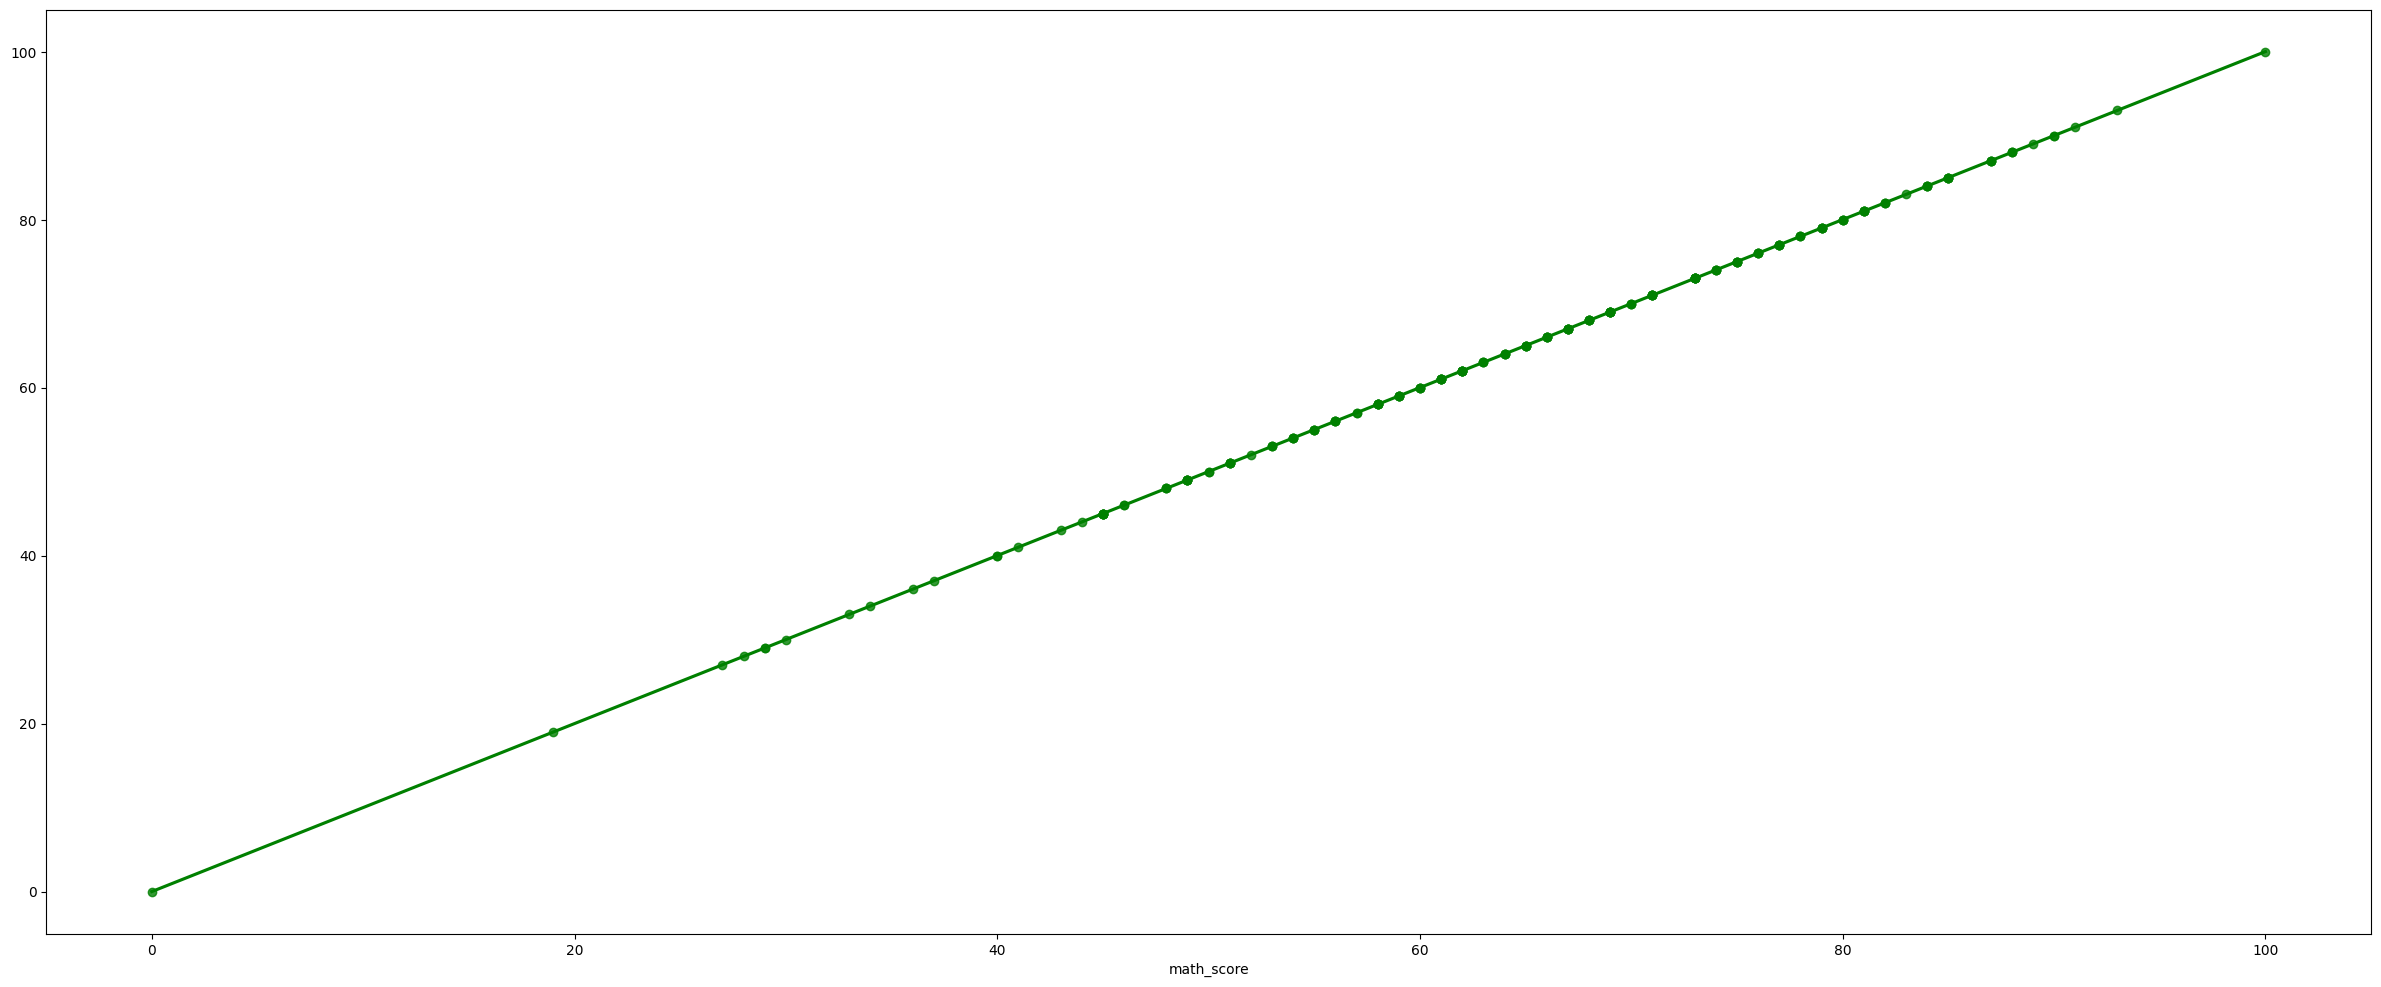

In [250]:
sns.regplot(x=y_test, y=y_pred, color='g')
plt.show()

In [252]:
pred_stud = pd.DataFrame({'Actual Value': y_test, 'Predicted Value': y_pred, 'Difference': y_test-y_pred})

In [254]:
pred_stud

,Actual Value,Predicted Value,Difference
521,91,91.0,-2.131628e-13
737,53,53.0,5.684342e-14
740,80,80.0,-7.105427e-14
660,74,74.0,-5.684342e-14
411,84,84.0,-1.421085e-13
...,...,...,...
408,52,52.0,1.705303e-13
332,62,62.0,1.350031e-13
208,74,74.0,-9.947598e-14
613,65,65.0,-7.105427e-14
